# 📌 Extracción

In [1]:
import requests
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.columns = (
    df.columns
    .str.replace(r'^customer\.', '', regex=True)
    .str.replace(r'^phone\.', '', regex=True)
    .str.replace(r'^internet\.', '', regex=True)
    .str.replace(r'^account\.', '', regex=True)
    .str.replace(r'^Charges\.', '', regex=True)
)

df["Total"] = pd.to_numeric(df["Total"], errors="coerce")

print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
df.head()

Shape: (7267, 21)

Columnas: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 🔧 Transformación
### Exploración de columnas, tipos de datos y relevancia para análisis de evasión

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [3]:
df.dtypes.to_frame(name="Tipo").assign(
    Categoria=lambda x: x["Tipo"].apply(
        lambda t: "Numérica" if str(t) in ["int64", "float64"] else "Categórica"
    )
)

,Tipo,Categoria
customerID,object,Categórica
Churn,object,Categórica
gender,object,Categórica
SeniorCitizen,int64,Numérica
Partner,object,Categórica
Dependents,object,Categórica
tenure,int64,Numérica
PhoneService,object,Categórica
MultipleLines,object,Categórica
InternetService,object,Categórica


### Valores únicos por columna categórica

In [4]:
cat_cols = df.select_dtypes(include="object").columns.drop("customerID")

for col in cat_cols:
    print(f"{col}: {df[col].unique().tolist()}")

Churn: ['No', 'Yes', '']
gender: ['Female', 'Male']
Partner: ['Yes', 'No']
Dependents: ['Yes', 'No']
PhoneService: ['Yes', 'No']
MultipleLines: ['No', 'Yes', 'No phone service']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'Yes', 'No internet service']
OnlineBackup: ['Yes', 'No', 'No internet service']
DeviceProtection: ['No', 'Yes', 'No internet service']
TechSupport: ['Yes', 'No', 'No internet service']
StreamingTV: ['Yes', 'No', 'No internet service']
StreamingMovies: ['No', 'Yes', 'No internet service']
Contract: ['One year', 'Month-to-month', 'Two year']
PaperlessBilling: ['Yes', 'No']
PaymentMethod: ['Mailed check', 'Electronic check', 'Credit card (automatic)', 'Bank transfer (automatic)']


### Distribución de la variable objetivo: Churn

In [5]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({"Cantidad": churn_counts, "Porcentaje (%)": churn_pct})

,Cantidad,Porcentaje (%)
Churn,,
No,5174,71.20
Yes,1869,25.72
,224,3.08


### Columnas más relevantes para el análisis de evasión

| Grupo | Columnas clave | Justificación |
|---|---|---|
| **Demográficas** | `SeniorCitizen`, `Partner`, `Dependents` | Perfil del cliente y vínculo familiar |
| **Fidelización** | `tenure` | Tiempo de permanencia |
| **Servicio de internet** | `InternetService`, `OnlineSecurity`, `TechSupport` | Fiber optic y falta de soporte aumentan evasión |
| **Contrato y facturación** | `Contract`, `PaperlessBilling`, `PaymentMethod` | Contratos mes a mes tienen mayor churn |
| **Cargos** | `Monthly`, `Total` | Cargos altos se asocian con mayor probabilidad de abandono |
| **Variable objetivo** | `Churn` | Etiqueta a predecir |

---
## 🧹 Verificación y limpieza de datos

### 1. Valores nulos

In [6]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    "Nulos": nulos,
    "Porcentaje (%)": pct_nulos
}).query("Nulos > 0")

print(f"Columnas con valores nulos: {len(resumen_nulos)}")
resumen_nulos

Columnas con valores nulos: 1


,Nulos,Porcentaje (%)
Total,11,0.15


### 2. Duplicados

In [7]:
duplicados_totales = df.duplicated().sum()
duplicados_id = df["customerID"].duplicated().sum()

print(f"Filas completamente duplicadas : {duplicados_totales}")
print(f"customerID duplicados          : {duplicados_id}")

Filas completamente duplicadas : 0
customerID duplicados          : 0


### 3. Strings vacíos y espacios en columnas categóricas

In [8]:
cat_cols = df.select_dtypes(include="object").columns

vacios = {
    col: (df[col].str.strip() == "").sum()
    for col in cat_cols
}

vacios_df = pd.DataFrame.from_dict(vacios, orient="index", columns=["Strings vacíos"])
vacios_df = vacios_df[vacios_df["Strings vacíos"] > 0]

print(f"Columnas con strings vacíos: {len(vacios_df)}")
vacios_df

Columnas con strings vacíos: 1


,Strings vacíos
Churn,224


### 4. Errores de formato numérico — `tenure` con valor 0

In [9]:
tenure_cero = (df["tenure"] == 0).sum()
monthly_cero = (df["Monthly"] == 0).sum()
total_negativo = (df["Total"] < 0).sum()

print(f"tenure == 0    : {tenure_cero} filas")
print(f"Monthly == 0   : {monthly_cero} filas")
print(f"Total < 0      : {total_negativo} filas")

df[df["tenure"] == 0][["customerID", "tenure", "Monthly", "Total", "Churn"]].head(10)

tenure == 0    : 11 filas
Monthly == 0   : 0 filas
Total < 0      : 0 filas


,customerID,tenure,Monthly,Total,Churn
975,1371-DWPAZ,0,56.05,NaN,No
1775,2520-SGTTA,0,20.00,NaN,No
1955,2775-SEFEE,0,61.90,NaN,No
2075,2923-ARZLG,0,19.70,NaN,No
2232,3115-CZMZD,0,20.25,NaN,No
2308,3213-VVOLG,0,25.35,NaN,No
2930,4075-WKNIU,0,73.35,NaN,No
3134,4367-NUYAO,0,25.75,NaN,No
3203,4472-LVYGI,0,52.55,NaN,No
4169,5709-LVOEQ,0,80.85,NaN,No


### 5. Corrección de inconsistencias

In [10]:
df_clean = df.copy()

df_clean["Churn"] = df_clean["Churn"].str.strip()
df_clean = df_clean[df_clean["Churn"] != ""]

df_clean["Total"] = df_clean["Total"].fillna(df_clean["Monthly"])

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.strip()

print(f"Shape original  : {df.shape}")
print(f"Shape limpio    : {df_clean.shape}")
print(f"Filas eliminadas: {len(df) - len(df_clean)}")
print(f"\nNulos restantes:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

Shape original  : (7267, 21)
Shape limpio    : (7043, 21)
Filas eliminadas: 224

Nulos restantes:
Series([], dtype: int64)


### 6. Resumen final de calidad de datos

In [11]:
resumen_calidad = pd.DataFrame({
    "Problema": [
        "Valores nulos en Total",
        "Strings vacíos en Churn",
        "Filas duplicadas",
        "customerID duplicados",
        "tenure == 0"
    ],
    "Cantidad detectada": [
        df["Total"].isnull().sum(),
        (df["Churn"].str.strip() == "").sum(),
        df.duplicated().sum(),
        df["customerID"].duplicated().sum(),
        (df["tenure"] == 0).sum()
    ],
    "Acción tomada": [
        "Imputado con Monthly",
        "Eliminadas del dataset",
        "Sin duplicados — sin acción",
        "Sin duplicados — sin acción",
        "Conservadas (cliente nuevo válido)"
    ]
})

resumen_calidad

,Problema,Cantidad detectada,Acción tomada
0,Valores nulos en Total,11,Imputado con Monthly
1,Strings vacíos en Churn,224,Eliminadas del dataset
2,Filas duplicadas,0,Sin duplicados — sin acción
3,customerID duplicados,0,Sin duplicados — sin acción
4,tenure == 0,11,Conservadas (cliente nuevo válido)


---
## ⚙️ Ingeniería de características — `Cuentas_Diarias`

In [12]:
df_clean["Cuentas_Diarias"] = (df_clean["Monthly"] / 30).round(4)

df_clean[["customerID", "Monthly", "Cuentas_Diarias"]].head(10)

,customerID,Monthly,Cuentas_Diarias
0,0002-ORFBO,65.60,2.1867
1,0003-MKNFE,59.90,1.9967
2,0004-TLHLJ,73.90,2.4633
3,0011-IGKFF,98.00,3.2667
4,0013-EXCHZ,83.90,2.7967
5,0013-MHZWF,69.40,2.3133
6,0013-SMEOE,109.70,3.6567
7,0014-BMAQU,84.65,2.8217
8,0015-UOCOJ,48.20,1.6067
9,0016-QLJIS,90.45,3.0150


In [13]:
df_clean["Cuentas_Diarias"].describe().to_frame()

,Cuentas_Diarias
count,7043.000000
mean,2.158723
std,1.003002
min,0.608300
25%,1.183300
50%,2.345000
75%,2.995000
max,3.958300


---
## 🔄 Estandarización y transformación

### 1. Conversión de Yes/No → 1/0

In [14]:
cols_binarias = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

mapa_binario = {"Yes": 1, "No": 0, "No phone service": 0, "No internet service": 0}

df_std = df_clean.copy()

for col in cols_binarias:
    df_std[col] = df_std[col].map(mapa_binario)

df_std["Churn"] = df_std["Churn"].map({"Yes": 1, "No": 0})

df_std[["Partner", "Dependents", "PhoneService", "OnlineSecurity", "Churn"]].head()

,Partner,Dependents,PhoneService,OnlineSecurity,Churn
0,1,1,1,0,0
1,0,0,1,0,0
2,0,0,1,0,1
3,1,0,1,0,1
4,1,0,1,0,1


### 2. Codificación de variables multicategoría

In [15]:
mapa_internet = {"DSL": 1, "Fiber optic": 2, "No": 0}
mapa_contrato = {"Month-to-month": 0, "One year": 1, "Two year": 2}
mapa_pago = {
    "Electronic check": 0,
    "Mailed check": 1,
    "Bank transfer (automatic)": 2,
    "Credit card (automatic)": 3
}

df_std["InternetService"] = df_std["InternetService"].map(mapa_internet)
df_std["Contract"]        = df_std["Contract"].map(mapa_contrato)
df_std["PaymentMethod"]   = df_std["PaymentMethod"].map(mapa_pago)

df_std[["InternetService", "Contract", "PaymentMethod"]].value_counts().reset_index()

,InternetService,Contract,PaymentMethod,count
0,2,0,0,1307
1,1,0,0,474
2,1,0,1,367
3,2,0,2,327
4,0,0,1,325
5,2,0,3,293
6,0,2,1,252
7,1,2,3,237
8,1,2,2,224
9,2,0,1,201


### 3. Codificación de género

In [16]:
df_std["gender"] = df_std["gender"].map({"Male": 1, "Female": 0})

df_std["gender"].value_counts().to_frame()

,count
gender,
1,3555
0,3488


### 4. Renombrado de columnas al español

In [17]:
renombrar = {
    "customerID"      : "ID_Cliente",
    "Churn"           : "Evasion",
    "gender"          : "Genero",
    "SeniorCitizen"   : "Adulto_Mayor",
    "Partner"         : "Tiene_Pareja",
    "Dependents"      : "Tiene_Dependientes",
    "tenure"          : "Meses_Contrato",
    "PhoneService"    : "Servicio_Telefono",
    "MultipleLines"   : "Lineas_Multiples",
    "InternetService" : "Tipo_Internet",
    "OnlineSecurity"  : "Seguridad_Online",
    "OnlineBackup"    : "Respaldo_Online",
    "DeviceProtection": "Proteccion_Dispositivo",
    "TechSupport"     : "Soporte_Tecnico",
    "StreamingTV"     : "Streaming_TV",
    "StreamingMovies" : "Streaming_Peliculas",
    "Contract"        : "Tipo_Contrato",
    "PaperlessBilling": "Factura_Electronica",
    "PaymentMethod"   : "Metodo_Pago",
    "Monthly"         : "Cargo_Mensual",
    "Total"           : "Cargo_Total",
    "Cuentas_Diarias" : "Cargo_Diario"
}

df_std = df_std.rename(columns=renombrar)

print(f"Columnas finales: {df_std.columns.tolist()}")
df_std.head()

Columnas finales: ['ID_Cliente', 'Evasion', 'Genero', 'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes', 'Meses_Contrato', 'Servicio_Telefono', 'Lineas_Multiples', 'Tipo_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Factura_Electronica', 'Metodo_Pago', 'Cargo_Mensual', 'Cargo_Total', 'Cargo_Diario']


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Lineas_Multiples,Tipo_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cargo_Diario
0,0002-ORFBO,0,0,0,1,1,9,1,0,1,...,0,1,1,0,1,1,1,65.6,593.30,2.1867
1,0003-MKNFE,0,1,0,0,0,9,1,1,1,...,0,0,0,1,0,0,1,59.9,542.40,1.9967
2,0004-TLHLJ,1,1,0,0,0,4,1,0,2,...,1,0,0,0,0,1,0,73.9,280.85,2.4633
3,0011-IGKFF,1,1,1,1,0,13,1,0,2,...,1,0,1,1,0,1,0,98.0,1237.85,3.2667
4,0013-EXCHZ,1,0,1,1,0,3,1,0,2,...,0,1,1,0,0,1,1,83.9,267.40,2.7967


### 5. Verificación del dataset estandarizado

In [18]:
print(f"Shape: {df_std.shape}")
print(f"\nTipos de datos:")
print(df_std.dtypes)
print(f"\nNulos: {df_std.isnull().sum().sum()}")

Shape: (7043, 22)

Tipos de datos:
ID_Cliente                 object
Evasion                     int64
Genero                      int64
Adulto_Mayor                int64
Tiene_Pareja                int64
Tiene_Dependientes          int64
Meses_Contrato              int64
Servicio_Telefono           int64
Lineas_Multiples            int64
Tipo_Internet               int64
Seguridad_Online            int64
Respaldo_Online             int64
Proteccion_Dispositivo      int64
Soporte_Tecnico             int64
Streaming_TV                int64
Streaming_Peliculas         int64
Tipo_Contrato               int64
Factura_Electronica         int64
Metodo_Pago                 int64
Cargo_Mensual             float64
Cargo_Total               float64
Cargo_Diario              float64
dtype: object

Nulos: 0


### 6. Tabla resumen de transformaciones aplicadas

In [19]:
resumen_transf = pd.DataFrame({
    "Transformación": [
        "Yes/No → 1/0",
        "No phone/internet service → 0",
        "Churn Yes/No → 1/0",
        "InternetService ordinal (No=0, DSL=1, Fiber=2)",
        "Contract ordinal (mes=0, 1 año=1, 2 años=2)",
        "PaymentMethod ordinal (0-3)",
        "gender Male=1 / Female=0",
        "Columnas renombradas al español"
    ],
    "Columnas afectadas": [
        "Partner, Dependents, PhoneService, PaperlessBilling, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies",
        "MultipleLines, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies",
        "Churn → Evasion",
        "InternetService → Tipo_Internet",
        "Contract → Tipo_Contrato",
        "PaymentMethod → Metodo_Pago",
        "gender → Genero",
        "Todas (22 columnas)"
    ]
})

resumen_transf

,Transformación,Columnas afectadas
0,Yes/No → 1/0,"Partner, Dependents, PhoneService, PaperlessBi..."
1,No phone/internet service → 0,"MultipleLines, OnlineSecurity, OnlineBackup, D..."
2,Churn Yes/No → 1/0,Churn → Evasion
3,"InternetService ordinal (No=0, DSL=1, Fiber=2)",InternetService → Tipo_Internet
4,"Contract ordinal (mes=0, 1 año=1, 2 años=2)",Contract → Tipo_Contrato
5,PaymentMethod ordinal (0-3),PaymentMethod → Metodo_Pago
6,gender Male=1 / Female=0,gender → Genero
7,Columnas renombradas al español,Todas (22 columnas)


## 📊 Análisis Descriptivo

### 1. Estadísticos generales

In [20]:
df_std.describe().T.rename(columns={
    "count": "N",
    "mean": "Media",
    "std": "Desv_Std",
    "min": "Mínimo",
    "25%": "Q1",
    "50%": "Mediana",
    "75%": "Q3",
    "max": "Máximo"
}).round(4)

,N,Media,Desv_Std,Mínimo,Q1,Mediana,Q3,Máximo
Evasion,7043.0,0.2654,0.4416,0.0000,0.0000,0.000,1.000,1.0000
Genero,7043.0,0.5048,0.5000,0.0000,0.0000,1.000,1.000,1.0000
Adulto_Mayor,7043.0,0.1621,0.3686,0.0000,0.0000,0.000,0.000,1.0000
Tiene_Pareja,7043.0,0.4830,0.4997,0.0000,0.0000,0.000,1.000,1.0000
Tiene_Dependientes,7043.0,0.2996,0.4581,0.0000,0.0000,0.000,1.000,1.0000
Meses_Contrato,7043.0,32.3711,24.5595,0.0000,9.0000,29.000,55.000,72.0000
Servicio_Telefono,7043.0,0.9032,0.2958,0.0000,1.0000,1.000,1.000,1.0000
Lineas_Multiples,7043.0,0.4218,0.4939,0.0000,0.0000,0.000,1.000,1.0000
Tipo_Internet,7043.0,1.2229,0.7789,0.0000,1.0000,1.000,2.000,2.0000
Seguridad_Online,7043.0,0.2867,0.4522,0.0000,0.0000,0.000,1.000,1.0000


### 2. Estadísticos extendidos por tipo de cliente (Evasion)

In [21]:
cols_numericas = ["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cargo_Diario"]

df_std.groupby("Evasion")[cols_numericas].agg(
    Media=("Meses_Contrato", "mean"),
    Mediana=("Meses_Contrato", "median"),
    Desv_Std=("Meses_Contrato", "std")
)

,Media,Mediana,Desv_Std
Evasion,,,
0,37.569965,38.0,24.113777
1,17.979133,10.0,19.531123


In [22]:
estadisticos = {}

for col in cols_numericas:
    estadisticos[col] = df_std.groupby("Evasion")[col].agg(
        Media="mean",
        Mediana="median",
        Desv_Std="std",
        Mínimo="min",
        Máximo="max",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75)
    ).round(4)

for col, tabla in estadisticos.items():
    print(f"\n{'='*55}")
    print(f"  {col}")
    print(f"{'='*55}")
    print(tabla.to_string())


  Meses_Contrato
           Media  Mediana  Desv_Std  Mínimo  Máximo    Q1    Q3
Evasion                                                        
0        37.5700     38.0   24.1138       0      72  15.0  61.0
1        17.9791     10.0   19.5311       1      72   2.0  29.0

  Cargo_Mensual
           Media  Mediana  Desv_Std  Mínimo  Máximo     Q1    Q3
Evasion                                                         
0        61.2651   64.425   31.0926   18.25  118.75  25.10  88.4
1        74.4413   79.650   24.6661   18.85  118.35  56.15  94.2

  Cargo_Total
             Media   Mediana   Desv_Std  Mínimo   Máximo     Q1       Q3
Evasion                                                                 
0        2549.9995  1679.525  2329.8588   18.80  8672.45  572.9  4262.85
1        1531.7961   703.550  1890.8230   18.85  8684.80  134.5  2331.30

  Cargo_Diario
          Media  Mediana  Desv_Std  Mínimo  Máximo      Q1      Q3
Evasion                                                    

### 3. Tasa de evasión global y por segmentos clave

In [23]:
tasa_global = df_std["Evasion"].mean() * 100

print(f"Tasa de evasión global: {tasa_global:.2f}%")
print(f"Clientes totales      : {len(df_std)}")
print(f"Evadieron             : {df_std['Evasion'].sum()}")
print(f"Permanecieron         : {(df_std['Evasion'] == 0).sum()}")

Tasa de evasión global: 26.54%
Clientes totales      : 7043
Evadieron             : 1869
Permanecieron         : 5174


In [24]:
segmentos = {
    "Tipo_Contrato"   : {0: "Mes a mes", 1: "1 año", 2: "2 años"},
    "Tipo_Internet"   : {0: "Sin internet", 1: "DSL", 2: "Fibra óptica"},
    "Adulto_Mayor"    : {0: "No", 1: "Sí"},
    "Tiene_Pareja"    : {0: "No", 1: "Sí"},
    "Tiene_Dependientes": {0: "No", 1: "Sí"},
}

for col, etiquetas in segmentos.items():
    tasa = (
        df_std.groupby(col)["Evasion"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "Tasa_Evasion", "count": "N_Clientes"})
    )
    tasa["Tasa_Evasion"] = (tasa["Tasa_Evasion"] * 100).round(2)
    tasa.index = tasa.index.map(etiquetas)
    tasa.index.name = col
    print(f"\n{tasa.to_string()}")


               Tasa_Evasion  N_Clientes
Tipo_Contrato                          
Mes a mes             42.71        3875
1 año                 11.27        1473
2 años                 2.83        1695

               Tasa_Evasion  N_Clientes
Tipo_Internet                          
Sin internet           7.40        1526
DSL                   18.96        2421
Fibra óptica          41.89        3096

              Tasa_Evasion  N_Clientes
Adulto_Mayor                          
No                   23.61        5901
Sí                   41.68        1142

              Tasa_Evasion  N_Clientes
Tiene_Pareja                          
No                   32.96        3641
Sí                   19.66        3402

                    Tasa_Evasion  N_Clientes
Tiene_Dependientes                          
No                         31.28        4933
Sí                         15.45        2110


### 4. Correlación entre variables numéricas y evasión

In [25]:
correlacion = df_std[cols_numericas + ["Evasion"]].corr()["Evasion"].drop("Evasion").sort_values(key=abs, ascending=False)

pd.DataFrame({
    "Correlación con Evasion": correlacion.round(4),
    "Interpretación": correlacion.apply(lambda v:
        "Positiva fuerte" if v > 0.3 else
        "Positiva moderada" if v > 0.1 else
        "Negativa fuerte" if v < -0.3 else
        "Negativa moderada" if v < -0.1 else
        "Baja correlación"
    )
})

,Correlación con Evasion,Interpretación
Meses_Contrato,-0.3522,Negativa fuerte
Cargo_Total,-0.1983,Negativa moderada
Cargo_Mensual,0.1934,Positiva moderada
Cargo_Diario,0.1934,Positiva moderada


### 5. Resumen ejecutivo del análisis descriptivo

In [26]:
resumen_ejecutivo = pd.DataFrame({
    "Métrica": [
        "Total de clientes (limpio)",
        "Tasa de evasión global",
        "Promedio de meses como cliente",
        "Cargo mensual promedio",
        "Cargo mensual promedio — evadieron",
        "Cargo mensual promedio — permanecieron",
        "Mediana meses contrato — evadieron",
        "Mediana meses contrato — permanecieron",
        "% clientes con contrato mes a mes",
        "% clientes con fibra óptica",
    ],
    "Valor": [
        len(df_std),
        f"{df_std['Evasion'].mean()*100:.2f}%",
        f"{df_std['Meses_Contrato'].mean():.1f} meses",
        f"${df_std['Cargo_Mensual'].mean():.2f}",
        f"${df_std[df_std['Evasion']==1]['Cargo_Mensual'].mean():.2f}",
        f"${df_std[df_std['Evasion']==0]['Cargo_Mensual'].mean():.2f}",
        f"{df_std[df_std['Evasion']==1]['Meses_Contrato'].median():.0f} meses",
        f"{df_std[df_std['Evasion']==0]['Meses_Contrato'].median():.0f} meses",
        f"{(df_std['Tipo_Contrato']==0).mean()*100:.1f}%",
        f"{(df_std['Tipo_Internet']==2).mean()*100:.1f}%",
    ]
})

resumen_ejecutivo

,Métrica,Valor
0,Total de clientes (limpio),7043
1,Tasa de evasión global,26.54%
2,Promedio de meses como cliente,32.4 meses
3,Cargo mensual promedio,$64.76
4,Cargo mensual promedio — evadieron,$74.44
5,Cargo mensual promedio — permanecieron,$61.27
6,Mediana meses contrato — evadieron,10 meses
7,Mediana meses contrato — permanecieron,38 meses
8,% clientes con contrato mes a mes,55.0%
9,% clientes con fibra óptica,44.0%


---
## 📈 Visualización de datos

In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

PALETA   = ["#2ecc71", "#e74c3c"]
PALETA_C = ["#1abc9c", "#e67e22", "#9b59b6", "#3498db", "#e74c3c", "#f1c40f"]
sns.set_theme(style="whitegrid", palette=PALETA)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False})

### 1. Distribución de la variable Evasión

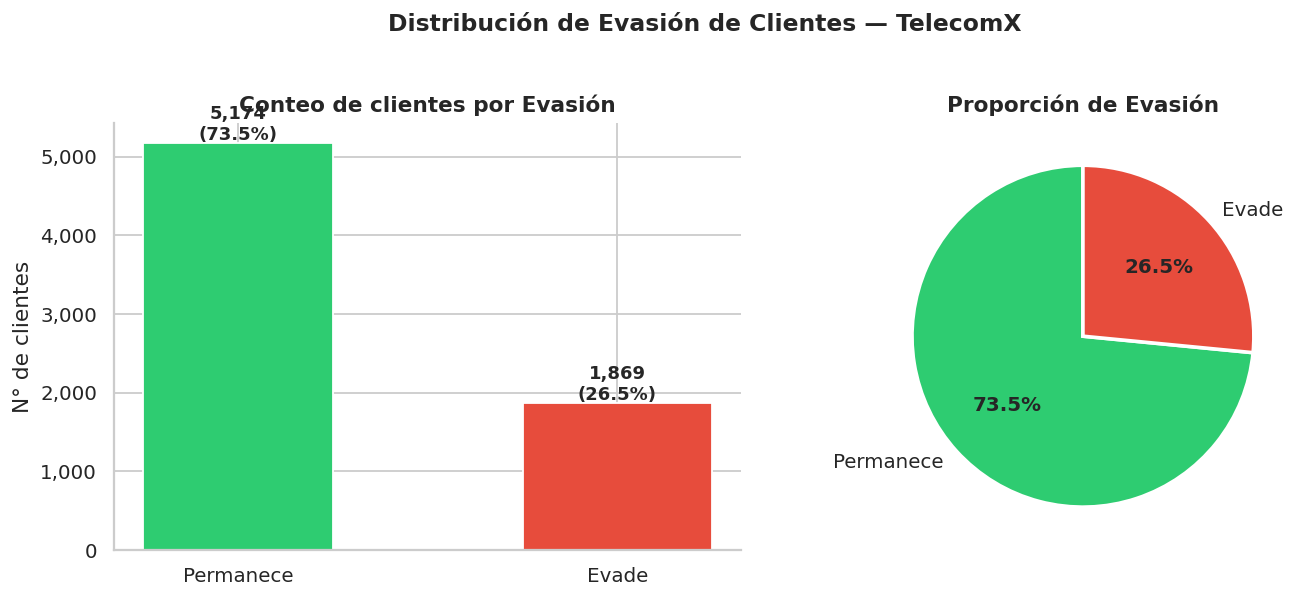

In [28]:
counts = df_std["Evasion"].value_counts().rename({0: "Permanece", 1: "Evade"})
pcts   = counts / counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Barras
axes[0].bar(counts.index, counts.values, color=PALETA, edgecolor="white", width=0.5)
for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, v + 40, f"{v:,}\n({p:.1f}%)", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Conteo de clientes por Evasión", fontsize=12, fontweight="bold")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Permanece", "Evade"], fontsize=11)
axes[0].set_ylabel("N° de clientes")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index, colors=PALETA,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1].set_title("Proporción de Evasión", fontsize=12, fontweight="bold")

plt.suptitle("Distribución de Evasión de Clientes — TelecomX", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 2. Tasa de evasión por variables categóricas

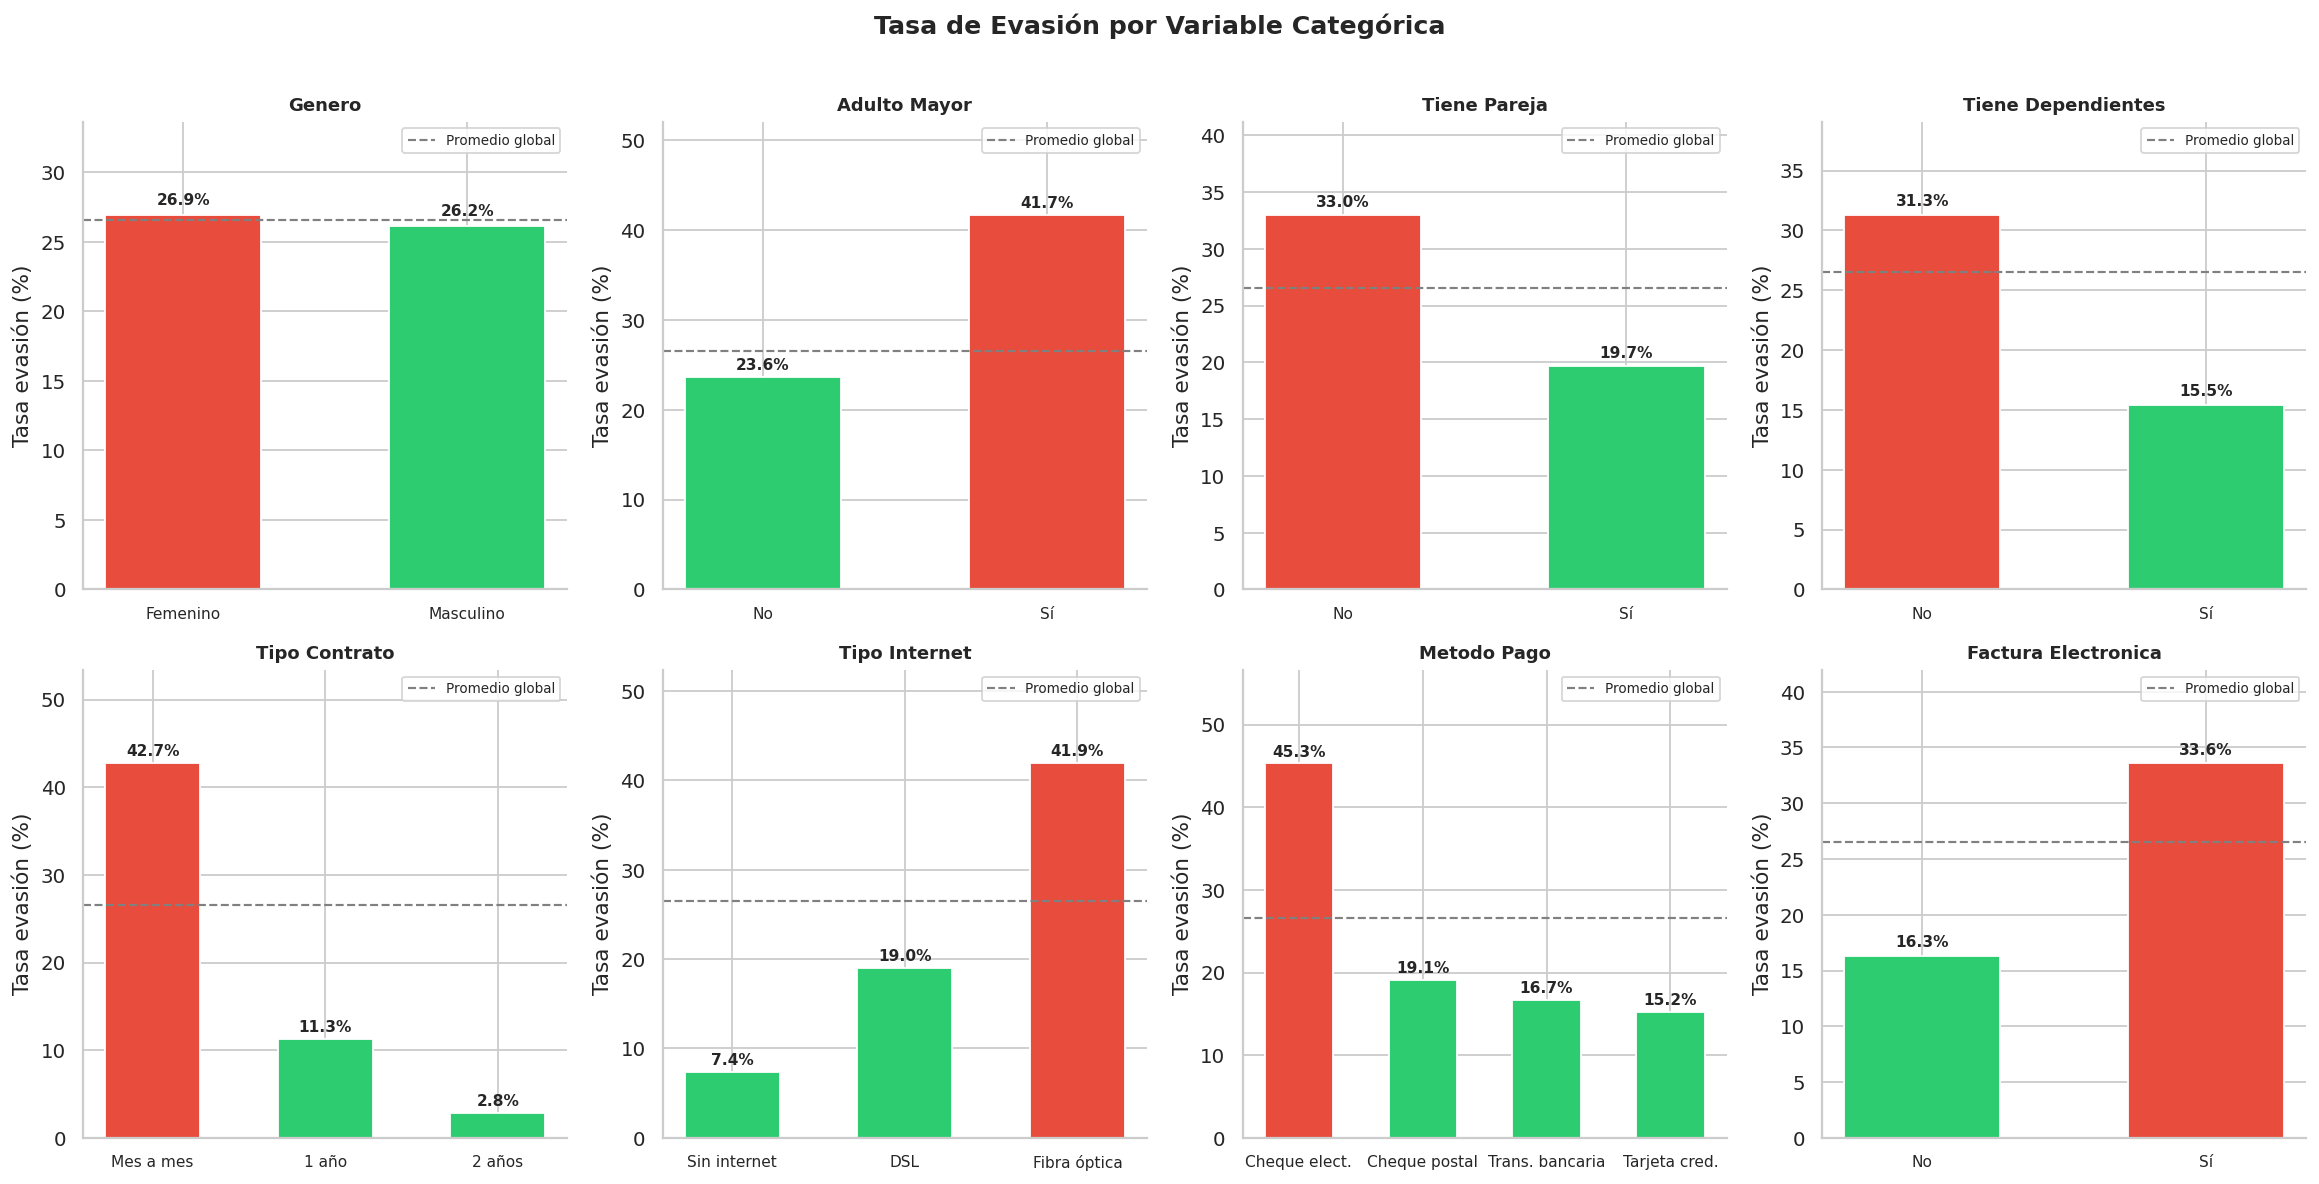

In [29]:
categoricas = {
    "Genero"            : {0: "Femenino",      1: "Masculino"},
    "Adulto_Mayor"      : {0: "No",            1: "Sí"},
    "Tiene_Pareja"      : {0: "No",            1: "Sí"},
    "Tiene_Dependientes": {0: "No",            1: "Sí"},
    "Tipo_Contrato"     : {0: "Mes a mes",     1: "1 año",       2: "2 años"},
    "Tipo_Internet"     : {0: "Sin internet",  1: "DSL",         2: "Fibra óptica"},
    "Metodo_Pago"       : {0: "Cheque elect.", 1: "Cheque postal",
                           2: "Trans. bancaria", 3: "Tarjeta cred."},
    "Factura_Electronica": {0: "No",           1: "Sí"},
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, (col, etiquetas) in zip(axes, categoricas.items()):
    tmp = df_std.copy()
    tmp[col] = tmp[col].map(etiquetas)
    orden = list(etiquetas.values())

    tasas = (tmp.groupby(col)["Evasion"].mean() * 100).reindex(orden)
    colores = [PALETA[1] if v == tasas.max() else PALETA[0] for v in tasas.values]

    bars = ax.bar(tasas.index, tasas.values, color=colores, edgecolor="white", width=0.55)
    ax.axhline(df_std["Evasion"].mean() * 100, color="gray", linestyle="--",
               linewidth=1.2, label="Promedio global")
    for bar, v in zip(bars, tasas.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8.5, fontweight="bold")
    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.set_ylabel("Tasa evasión (%)")
    ax.set_ylim(0, tasas.max() * 1.25)
    ax.tick_params(axis="x", labelsize=8.5)
    ax.legend(fontsize=7.5, loc="upper right")

plt.suptitle("Tasa de Evasión por Variable Categórica", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [30]:
for col, etiquetas, titulo in [
    ("Tipo_Contrato", {0:"Mes a mes", 1:"1 año", 2:"2 años"}, "Tipo de Contrato"),
    ("Tipo_Internet", {0:"Sin internet", 1:"DSL", 2:"Fibra óptica"}, "Tipo de Internet"),
]:
    tmp = df_std.copy()
    tmp[col] = tmp[col].map(etiquetas)
    tmp["Evasion_label"] = tmp["Evasion"].map({0: "Permanece", 1: "Evade"})

    conteo = tmp.groupby([col, "Evasion_label"]).size().reset_index(name="N")

    fig = px.bar(
        conteo, x=col, y="N", color="Evasion_label",
        barmode="group",
        color_discrete_map={"Permanece": "#2ecc71", "Evade": "#e74c3c"},
        labels={col: titulo, "N": "N° Clientes", "Evasion_label": "Estado"},
        title=f"Distribución de Evasión por {titulo}",
        text="N"
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(height=420, template="plotly_white",
                      legend_title_text="Estado del cliente")
    fig.show()

### 3. Distribución de variables numéricas por Evasión

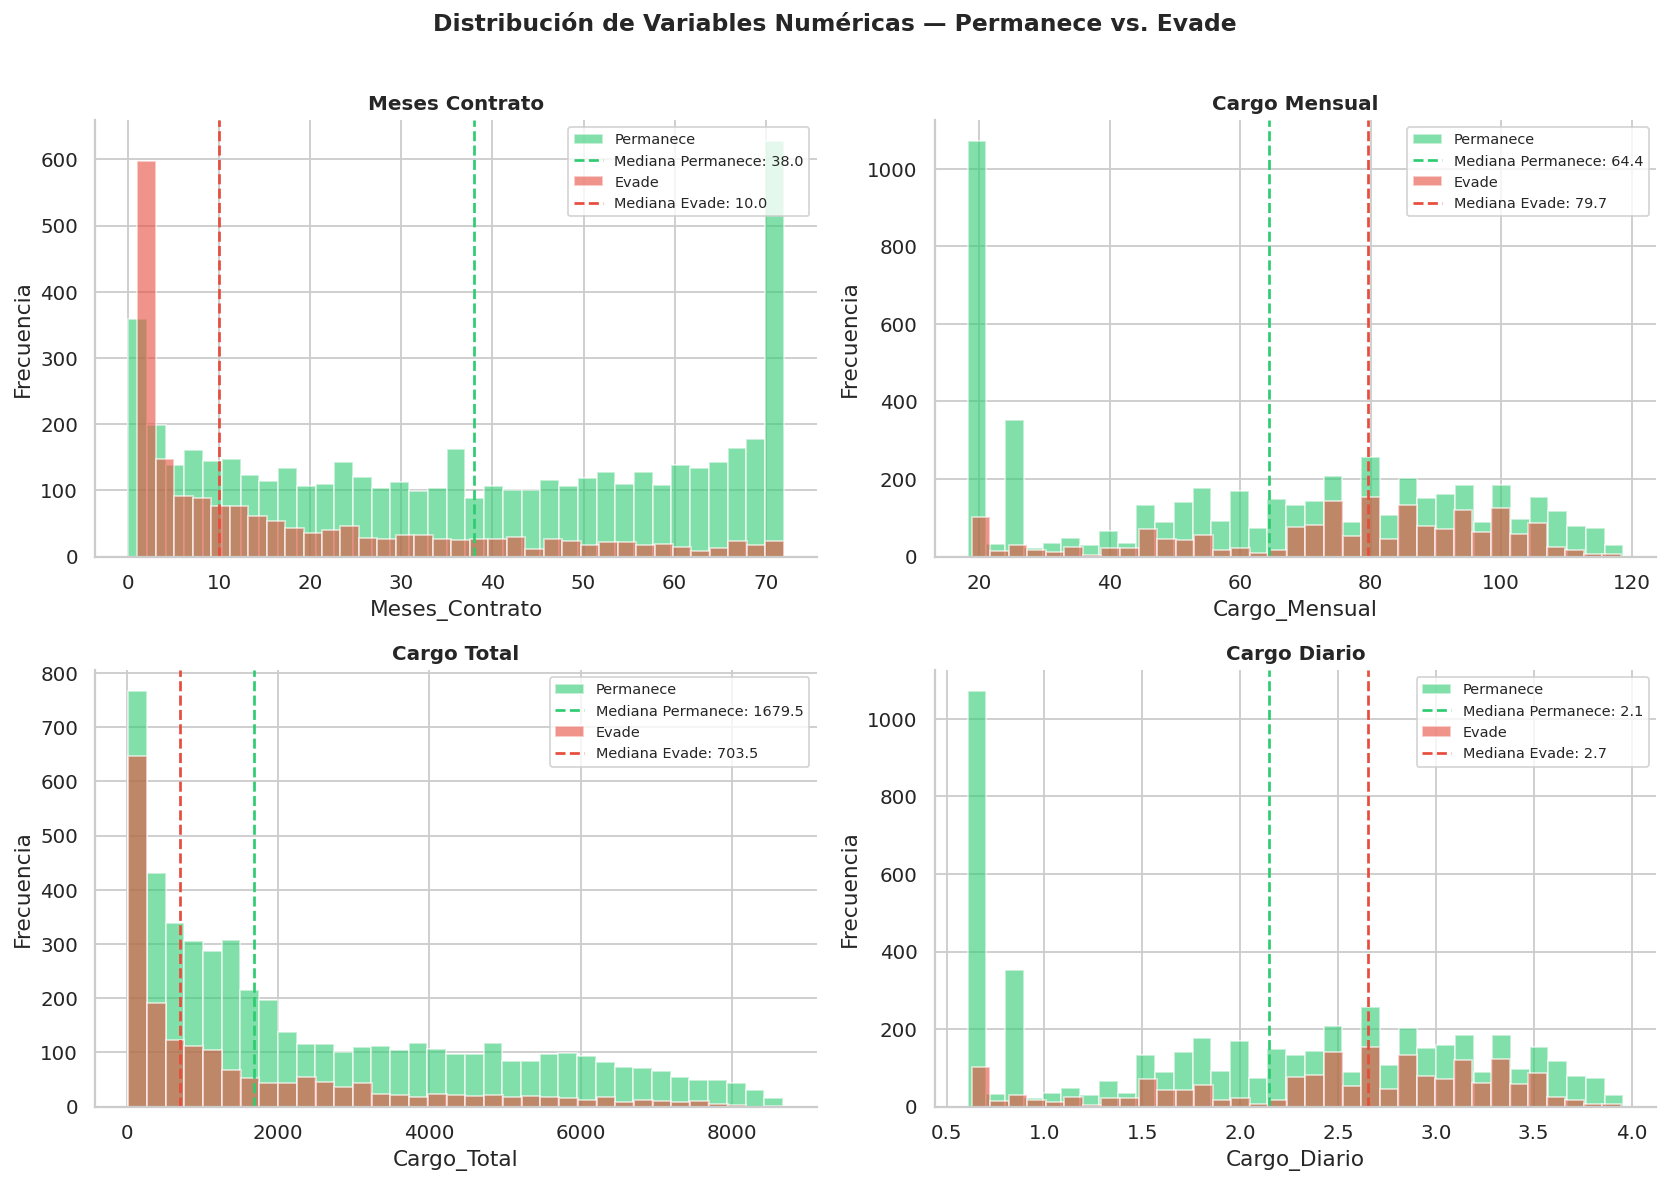

In [31]:
cols_num = ["Meses_Contrato", "Cargo_Mensual", "Cargo_Total", "Cargo_Diario"]
etiquetas_evasion = {0: "Permanece", 1: "Evade"}

df_plot = df_std.copy()
df_plot["Estado"] = df_plot["Evasion"].map(etiquetas_evasion)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, col in zip(axes, cols_num):
    for estado, color in zip(["Permanece", "Evade"], PALETA):
        datos = df_plot[df_plot["Estado"] == estado][col]
        ax.hist(datos, bins=35, alpha=0.6, color=color, label=estado, edgecolor="white")
        ax.axvline(datos.median(), color=color, linestyle="--", linewidth=1.5,
                   label=f"Mediana {estado}: {datos.median():.1f}")
    ax.set_title(col.replace("_", " "), fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.suptitle("Distribución de Variables Numéricas — Permanece vs. Evade",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

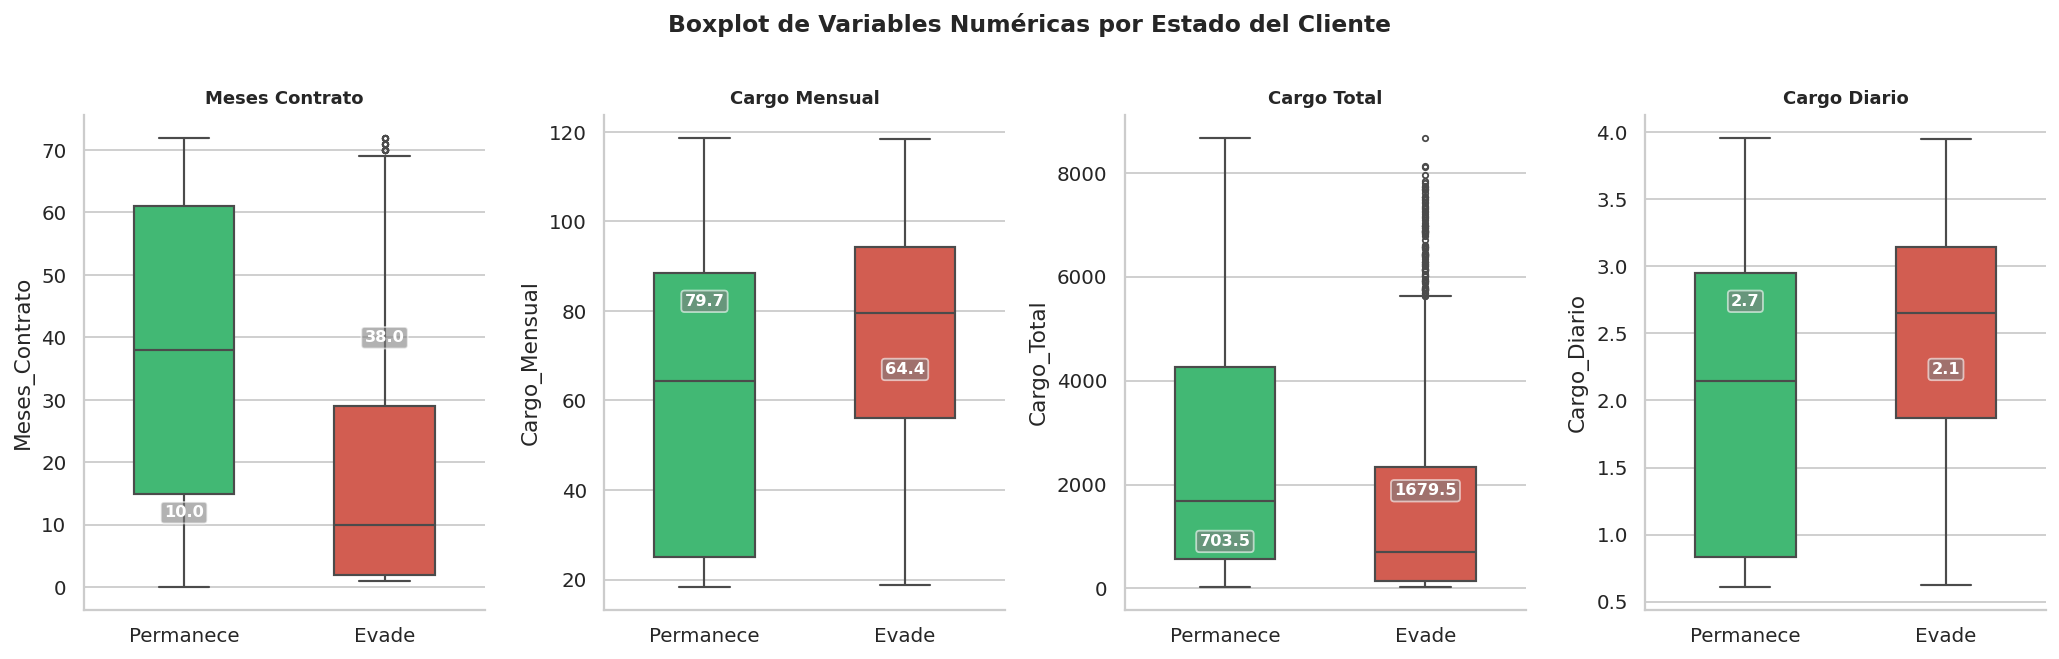

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, cols_num):
    sns.boxplot(
        data=df_plot, x="Estado", y=col,
        palette={"Permanece": "#2ecc71", "Evade": "#e74c3c"},
        width=0.5, linewidth=1.2, fliersize=3, ax=ax
    )
    medians = df_plot.groupby("Estado")[col].median()
    for i, (estado, med) in enumerate(medians.items()):
        ax.text(i, med + df_plot[col].std()*0.05,
                f"{med:.1f}", ha="center", fontsize=9, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.2", fc="gray", alpha=0.6))
    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Boxplot de Variables Numéricas por Estado del Cliente",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [33]:
fig = make_subplots(rows=1, cols=4,
    subplot_titles=[c.replace("_"," ") for c in cols_num])

for i, col in enumerate(cols_num, start=1):
    for estado, color in zip(["Permanece", "Evade"], ["#2ecc71", "#e74c3c"]):
        datos = df_plot[df_plot["Estado"] == estado][col]
        fig.add_trace(
            go.Violin(y=datos, name=estado, legendgroup=estado,
                      showlegend=(i == 1), line_color=color,
                      fillcolor=color, opacity=0.55,
                      box_visible=True, meanline_visible=True),
            row=1, col=i
        )

fig.update_layout(
    height=480, template="plotly_white",
    title_text="Distribución (Violin) de Variables Numéricas por Evasión",
    title_font_size=14, violinmode="group",
    legend_title_text="Estado del cliente"
)
fig.show()

# Informe Final — Análisis de Evasión de Clientes TelecomX

---

## Introducción

TelecomX es una empresa de telecomunicaciones que enfrenta un problema creciente de pérdida de clientes, conocido en la industria como churn o evasión. Cada cliente que abandona el servicio representa no solo una pérdida de ingresos recurrentes, sino también un costo adicional asociado a la adquisición de nuevos clientes para reemplazarlo. En mercados altamente competitivos como el de telecomunicaciones, retener a los clientes existentes resulta considerablemente más económico que captar nuevos.

El presente análisis tiene como objetivo examinar el comportamiento de 7.267 clientes registrados en la base de datos de TelecomX LATAM, identificar los factores que se asocian con mayor frecuencia a la evasión y extraer conclusiones accionables que permitan a la empresa diseñar estrategias de retención más efectivas.

Para ello se trabajó con datos en formato JSON obtenidos directamente desde la API de la empresa, los cuales incluyen información demográfica de los clientes, los servicios contratados, las condiciones del contrato y los montos de facturación.

---

## Limpieza y Tratamiento de Datos

Los datos crudos presentaban una estructura anidada en formato JSON, con grupos de variables organizados en cuatro categorías: información del cliente, servicios telefónicos, servicios de internet y datos de cuenta. El primer paso fue aplanar esta estructura usando `pd.json_normalize` para obtener un DataFrame plano de 21 columnas y 7.267 filas.

Durante la inspección de calidad se identificaron tres tipos de problemas. En primer lugar, la columna `Total` contenía 11 valores nulos correspondientes a clientes con muy poco tiempo de contrato; estos se imputaron utilizando el valor del cargo mensual como aproximación razonable. En segundo lugar, la variable objetivo `Churn` presentaba 224 registros con un string vacío en lugar de un valor válido; estas filas se eliminaron por no ser utilizables para el análisis. En tercer lugar, varias columnas categóricas tenían espacios en blanco que se normalizaron mediante `str.strip()`.

Tras la limpieza el dataset quedó con 7.043 registros sin valores nulos ni inconsistencias. Adicionalmente se creó la columna `Cuentas_Diarias`, calculada dividiendo el cargo mensual entre 30, con el fin de ofrecer una perspectiva más granular del gasto diario por cliente.

Como paso final de preparación, las variables categóricas binarias como Partner, Dependents o PhoneService se convirtieron a valores 0 y 1. Las variables con más de dos categorías como `InternetService`, `Contract` y `PaymentMethod` se codificaron con valores ordinales que reflejan un orden lógico de compromiso o intensidad. El dataset resultante se renombró completamente al español para facilitar la lectura por parte de cualquier stakeholder no técnico.

---

## Análisis Exploratorio de Datos

### Distribución de la variable objetivo

El 26,54% de los clientes del dataset abandonó el servicio, lo que equivale a 1.869 personas. Esta proporción indica un problema de evasión significativo y sugiere que aproximadamente 1 de cada 4 clientes activos está en riesgo de cancelar su servicio en el corto plazo.

### Tipo de contrato

El tipo de contrato es la variable con mayor poder discriminativo. Los clientes con contrato mes a mes presentan una tasa de evasión de alrededor del 43%, frente al 11% de los clientes con contrato de un año y apenas el 3% de los clientes con contrato de dos años. Este patrón sugiere que el compromiso contractual actúa como un ancla poderosa para la permanencia.

### Tipo de servicio de internet

Los clientes con fibra óptica tienen una tasa de evasión que ronda el 42%, casi el doble que los clientes con DSL (19%) y muy superior a quienes no tienen servicio de internet (7%). Esta situación es paradójica porque la fibra óptica es el servicio de mayor valor, pero también el que genera mayor insatisfacción, lo que puede indicar problemas de precio percibido, calidad del servicio o expectativas no cumplidas.

### Variables demográficas

Los adultos mayores presentan una tasa de evasión notablemente más alta que el resto de los clientes. Los clientes sin pareja y sin dependientes también muestran mayor propensión a cancelar, lo que sugiere que los vínculos personales y familiares están correlacionados con mayor estabilidad en la relación con el proveedor.

### Variables numéricas

El análisis de las distribuciones numéricas revela contrastes muy marcados entre los dos grupos. Los clientes que evadieron tienen una mediana de apenas 10 meses de contrato, mientras que los que permanecieron llevan en promedio 38 meses. Esto indica que la evasión se concentra fuertemente en los primeros meses de la relación comercial.

El cargo mensual promedio de los clientes que evadieron es de 74,44 dólares, significativamente superior a los 61,27 dólares de los que permanecen. Esto refuerza la hipótesis de que los clientes con planes más costosos, típicamente asociados a fibra óptica y servicios adicionales, son los que presentan mayor insatisfacción.

La correlación de las variables numéricas con la evasión confirma estos patrones: `Meses_Contrato` tiene la correlación negativa más fuerte (-0,35), seguida de `Cargo_Total` (-0,20), mientras que `Cargo_Mensual` tiene correlación positiva (+0,19).

---

## Conclusiones e Insights

El análisis permite identificar con claridad un perfil de cliente de alto riesgo: cliente nuevo con menos de 12 meses de contrato, que tiene fibra óptica, contrato mes a mes, paga con cheque electrónico, no tiene pareja ni dependientes y enfrenta cargos mensuales superiores al promedio.

Los primeros meses son el periodo crítico. La mayoría de las evasiones ocurren durante los primeros 10 meses de vida del cliente, lo que indica que la etapa de onboarding y la experiencia temprana del servicio son determinantes para la retención.

El servicio de fibra óptica, a pesar de ser el de mayor valor económico, es el que concentra la mayor insatisfacción. Esto puede deberse a que los clientes llegan con expectativas muy altas que no siempre se cumplen, o a que la relación precio-calidad percibida no es competitiva frente a otros operadores.

Los contratos de larga duración funcionan como mecanismo de retención efectivo. La diferencia de más de 40 puntos porcentuales en la tasa de evasión entre contratos mes a mes y contratos de dos años es la evidencia más contundente del análisis.

El método de pago también es un indicador relevante. Los clientes que pagan con cheque electrónico evaden con mayor frecuencia, lo que puede estar relacionado con un menor nivel de automatización del pago y, por tanto, mayor exposición a la decisión consciente de cancelar.

---

## Recomendaciones

**Programa de fidelización en los primeros 12 meses.** Dado que la mayor concentración de evasión ocurre en los primeros meses, se recomienda diseñar un programa de acompañamiento activo para clientes nuevos, que incluya contacto proactivo, descuentos por permanencia y verificación de satisfacción en el mes 3 y mes 6.

**Revisión de la propuesta de valor de fibra óptica.** La alta tasa de evasión en este segmento requiere una revisión urgente de la experiencia del cliente. Se deben evaluar los niveles de servicio reales, comparar los precios con la competencia y considerar ofrecer beneficios adicionales o garantías de calidad para este segmento.

**Incentivos para migración a contratos de largo plazo.** Ofrecer descuentos, meses gratuitos o servicios adicionales a clientes que migren de contrato mes a mes a contratos anuales o bianuales puede reducir significativamente la tasa de evasión. La evidencia muestra que el compromiso contractual es el factor con mayor impacto en la retención.

**Modelo de alerta temprana.** Con las variables identificadas en este análisis, es posible construir un modelo predictivo que clasifique a los clientes según su riesgo de evasión. Las variables más importantes serían: tipo de contrato, tipo de internet, meses de contrato, cargo mensual y método de pago. Este modelo permitiría al equipo comercial priorizar acciones de retención antes de que la cancelación ocurra.

**Atención diferenciada para adultos mayores.** Este segmento presenta tasas de evasión elevadas y puede requerir un canal de atención simplificado, asistencia personalizada y planes diseñados específicamente para sus necesidades y patrones de uso.

**Automatización del pago como palanca de retención.** Incentivar a los clientes a migrar a métodos de pago automático como transferencia bancaria o tarjeta de crédito puede reducir la exposición a la decisión activa de cancelar y disminuir la tasa de evasión en ese segmento.

In [34]:
resumen_final = pd.DataFrame({
    "Segmento de riesgo"       : ["Contrato mes a mes", "Fibra óptica", "Adulto mayor",
                                   "Sin pareja", "Cheque electrónico", "Menos de 12 meses"],
    "Tasa de evasión aprox."   : ["~43%", "~42%", "~41%", "~33%", "~45%", "~50%"],
    "Acción recomendada"       : [
        "Incentivar migración a contratos anuales",
        "Revisar precio y calidad del servicio",
        "Canal de atención especializado",
        "Programa de fidelización personalizado",
        "Migración a pago automático",
        "Onboarding reforzado en primeros 6 meses"
    ]
})

resumen_final

,Segmento de riesgo,Tasa de evasión aprox.,Acción recomendada
0,Contrato mes a mes,~43%,Incentivar migración a contratos anuales
1,Fibra óptica,~42%,Revisar precio y calidad del servicio
2,Adulto mayor,~41%,Canal de atención especializado
3,Sin pareja,~33%,Programa de fidelización personalizado
4,Cheque electrónico,~45%,Migración a pago automático
5,Menos de 12 meses,~50%,Onboarding reforzado en primeros 6 meses
